In [2]:
import numpy as np
import matplotlib.pyplot as plt
import subprocess
import os
import time

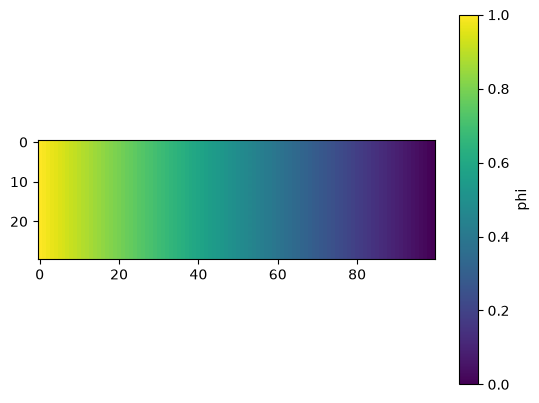

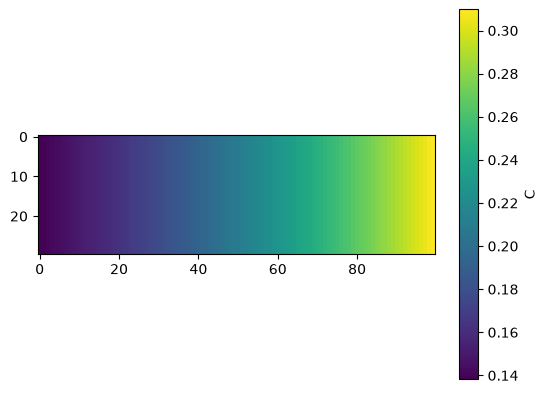

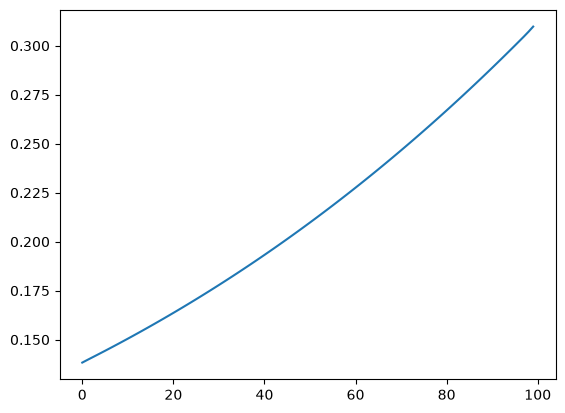

In [9]:
data_phi = np.loadtxt("result_phi.csv")
data_C = np.loadtxt("result_C.csv")

plt.figure()
plt.imshow(data_phi)
plt.colorbar(label='phi')

plt.figure()
plt.imshow(data_C)
plt.colorbar(label='C')

plt.figure()
plt.plot(data_C[10, :])

C:\Users\admin\AppData\Local\Temp\ipykernel_9532\2732680587.py:63: DeprecationWarning: pybamm.CasadiSolver is deprecated and will be removed in a future release. Use pybamm.IDAKLUSolver instead.
  solver = pb.CasadiSolver()


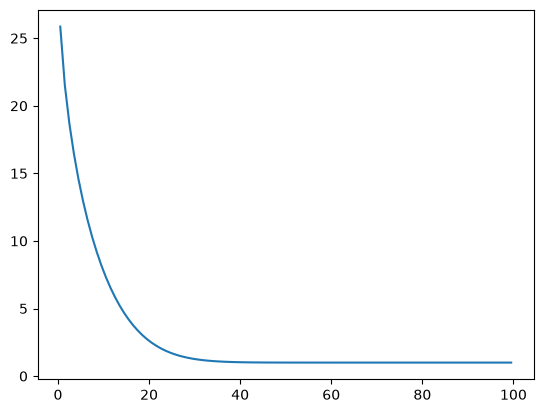

In [ ]:
import pybamm as pb

model = pb.BaseModel()

x = pb.SpatialVariable("x", domain="electrolyte", coord_sys="cartesian")
C = pb.Variable("C", domain="electrolyte")
phi = pb.Variable("phi", domain="electrolyte")

Deff = pb.Scalar(1e-2)  # Effective diffusion coefficient (m^2/s)
F = pb.Scalar(1)  # Faraday's constant (C/mol)
kappa = pb.Scalar(0.1)  # Conductivity (S/m)
D = pb.Scalar(10.0) # Diffusion coefficient (m^2/s)
RT = pb.Scalar(3)  # Gas constant times temperature (J/mol)
L = 100 # Length of the domain (m)
C0 = 1.0  # Initial concentration (mol/m^3)

model.rhs = {C: D * pb.laplacian(C) + (D * F / RT) * pb.div(C * pb.grad(phi))}
model.algebraic = {phi: kappa * pb.laplacian(phi) + F * Deff * pb.laplacian(C)}

model.variables = {
    "C": C,
    "phi": phi
}

lphi = 1.0
rphi = 0.0

model.boundary_conditions = {
    C: {
        "left": (-(F / RT) * pb.boundary_value(C, "left") * pb.boundary_value(pb.grad(phi), "left"), "Neumann"),
        "right": (- (F / RT) * pb.boundary_value(C, "right") * pb.boundary_value(pb.grad(phi), "right"), "Neumann")
    },
    phi: {
        "left": (pb.Scalar(lphi), "Dirichlet"),
        "right": (pb.Scalar(rphi), "Dirichlet")
    }
}

model.initial_conditions = {
    C: C0,
    phi : lphi + (rphi - lphi) * x / L
}

geometry = {
    "electrolyte": {
        x : {
            "min": pb.Scalar(0),
            "max": pb.Scalar(L)
        }
    }
}

mesh = pb.Mesh(
    geometry,
    {"electrolyte": pb.Uniform1DSubMesh},
    {x: 100}
)

spatial_methods = {"electrolyte": pb.FiniteVolume()}
disc = pb.Discretisation(mesh, spatial_methods)
disc.process_model(model)

solver = pb.CasadiSolver()
solution = solver.solve(model, t_eval=np.linspace(0, 10, 100))


x_nodes = mesh["electrolyte"].nodes
plt.plot(x_nodes, solution["C"].entries[:, -1])